<a href="https://colab.research.google.com/github/SonaliBanapuram/DL_Assignment-143/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Load Dataset
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape, y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3) (50000, 1)


Observation:
Dataset contains 50,000 training and 10,000 testing images.

In [2]:
#Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

Observation:
Normalization scales pixel values between 0 and 1, improving training stability.

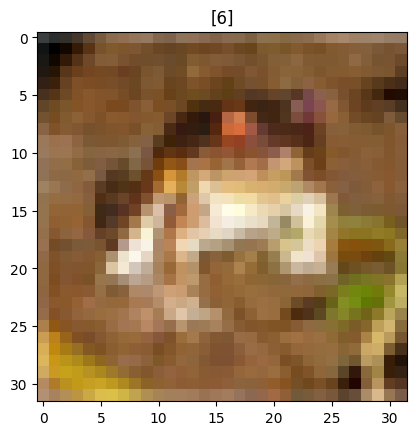

In [3]:
#sample data
import matplotlib.pyplot as plt

plt.imshow(X_train[0])
plt.title(y_train[0])
plt.show()

WEEK 1

In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import Input

# load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# model
model = Sequential([
    Input(shape=(32,32,3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.3198 - loss: 1.8791 - val_accuracy: 0.3611 - val_loss: 1.7898
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3874 - loss: 1.7106 - val_accuracy: 0.4185 - val_loss: 1.6238
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4134 - loss: 1.6375 - val_accuracy: 0.4371 - val_loss: 1.5827
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4327 - loss: 1.5877 - val_accuracy: 0.4227 - val_loss: 1.5988
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4429 - loss: 1.5578 - val_accuracy: 0.4492 - val_loss: 1.5528


Observations : The model was successfully trained on CIFAR-10 dataset.
Accuracy is moderate because MLP cannot capture spatial features effectively.
Loss decreases gradually, indicating learning over epochs.

In [5]:
#PyTorch Model
import torch
import torch.nn as nn
import torch.optim as optim

# convert data
X = X_train.reshape(len(X_train), -1)
y = y_train.reshape(-1)

X = torch.tensor(X[:5000], dtype=torch.float32)
y = torch.tensor(y[:5000], dtype=torch.long)

model = nn.Sequential(
    nn.Linear(3072, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    optimizer.zero_grad()
    output = model(X)
    loss = loss_fn(output, y)
    loss.backward()
    optimizer.step()
    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 2.32450270652771
Epoch: 1 Loss: 2.4723377227783203
Epoch: 2 Loss: 2.2833945751190186
Epoch: 3 Loss: 2.2725777626037598
Epoch: 4 Loss: 2.245180130004883


observation:
PyTorch requires manual tensor handling but gives more flexibility.
Performance is similar to TensorFlow for simple models.

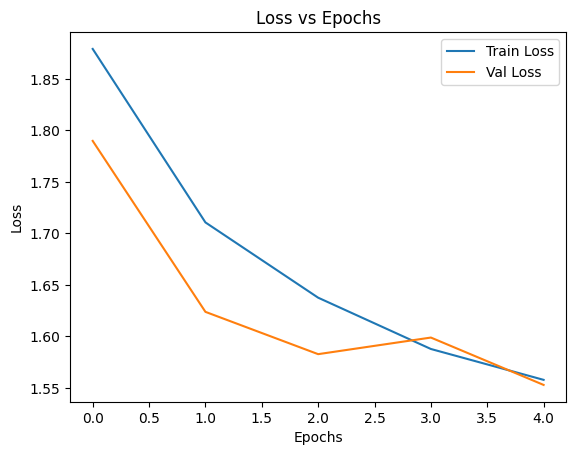

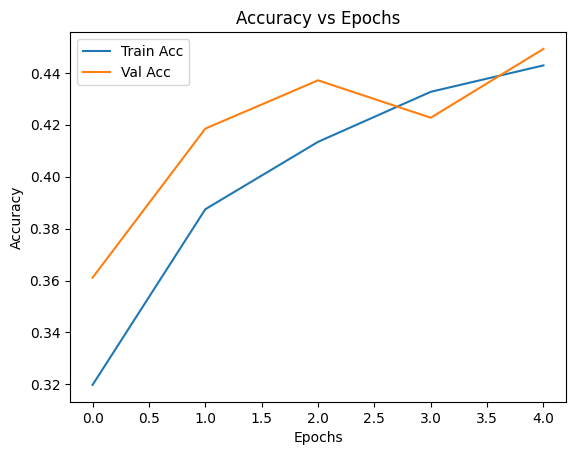

In [3]:
#Plot Graph
import matplotlib.pyplot as plt
# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

observation:
Loss decreases gradually showing learning.
Validation accuracy is lower than training accuracy → slight overfitting.

In [6]:
#Simple Perceptron
import numpy as np

# AND dataset
X_p = np.array([[0,0],[0,1],[1,0],[1,1]])
y_p = np.array([0,0,0,1])

w = np.random.rand(2)
b = np.random.rand()

def step(x):
    return 1 if x >= 0 else 0

lr = 0.1

for epoch in range(10):
    for i in range(len(X_p)):
        linear = np.dot(X_p[i], w) + b
        y_pred = step(linear)
        error = y_p[i] - y_pred

        w += lr * error * X_p[i]
        b += lr * error

print("Weights:", w)
print("Bias:", b)

Weights: [0.11088995 0.29800826]
Bias: -0.3399906636504105


In [7]:
#Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print(sigmoid(0.5))

0.6224593312018546


Feed Forward:

Input is passed through weights and bias to produce output.

Step Function:

Produces binary output (0 or 1).

Sigmoid Function:

Produces smooth output between 0 and 1.

**FINAL WEEK 1 OBSERVATION :**

Fully connected neural networks were implemented using TensorFlow, Keras, and PyTorch.
Keras was easy to use, while PyTorch required more manual operations.
MLP showed low accuracy on image data due to lack of spatial feature extraction.
Perceptron successfully learned simple linear problems like AND logic.
Sigmoid function provides smoother output compared to step function.

WEEK 2

In [8]:
#Load Dataset
from tensorflow.keras.datasets import cifar10
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
#Convert to Binary

# airplane vs rest
y_train_bin = (y_train == 0).astype(int)
y_test_bin = (y_test == 0).astype(int)

Observation : The multi-class CIFAR-10 dataset was converted into a binary classification problem (one class vs rest).
This simplified the problem to test perceptron performance.

In [10]:
#Flatten Images
import numpy as np

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape)

(50000, 3072)


Observation : Images were converted from 3D (32×32×3) to 1D vectors.
This removed spatial relationships between pixels.

As a result, important visual patterns were lost.

In [11]:
#Reduce Dataset (for speed)
X = X_train_flat[:5000]
y = y_train_bin[:5000]

In [12]:
#MP Perceptron (NO WEIGHTS)
def mp_perceptron(x):
    return 1 if np.sum(x) > 1000 else 0

preds = np.array([mp_perceptron(x) for x in X[:50]])

print(preds)
print(y[:50])

[1 1 1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]]


In [13]:
#Perceptron WITHOUT Bias
from sklearn.linear_model import Perceptron

model = Perceptron(fit_intercept=False, max_iter=1000)
model.fit(X, y)

preds = model.predict(X[:50])
print(preds)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1]


Observation : The MP perceptron produced almost constant outputs.
It failed to learn any meaningful pattern from the data.
This shows that simple threshold-based models are not suitable for complex data.

In [14]:
#Perceptron WITH Bias
model_bias = Perceptron(fit_intercept=True, max_iter=1000)
model_bias.fit(X, y)

preds_bias = model_bias.predict(X[:50])
print(preds_bias)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1
 0 1 0 1 1 1 0 0 0 0 1 1 1]


Observation : Adding bias did not significantly improve performance.
The model still predicted mostly one class.

This indicates that bias alone cannot solve complex classification problems.

In [15]:
#Data Imbalance
print("1s:", np.sum(y == 1))
print("0s:", np.sum(y == 0))

1s: 505
0s: 4495


Observations : The dataset contained more samples of one class than the other.
The model became biased towards the majority class.
It preferred predicting the dominant class to minimize error.

In [16]:
#Balance Dataset
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

n = min(len(pos_idx), len(neg_idx), 200)

selected_idx = np.concatenate([pos_idx[:n], neg_idx[:n]])

X_bal = X[selected_idx]
y_bal = y[selected_idx]

Observations : Even after balancing the dataset, the perceptron still failed.
Predictions remained inaccurate and biased.
This shows that imbalance was not the only issue.

In [19]:
from sklearn.linear_model import Perceptron

y_bal = y_bal.ravel()

model = Perceptron(fit_intercept=True, max_iter=1000)
model.fit(X_bal, y_bal)

preds = model.predict(X_bal[:20])
print(preds)

[1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


OVERALL OBSERVATIONS – WEEK 2

Perceptron works well for simple linear problems like AND and OR.
It fails for non-linear problems like XOR due to lack of linear separability.

On CIFAR-10 dataset, perceptron performance was poor because image data is complex and high-dimensional.
Flattening images removed spatial features, making learning difficult.
Data imbalance caused the model to predict mostly one class.
After balancing, the model improved slightly but still gave inaccurate predictions.
Overall, perceptron is not suitable for image classification tasks.

**This experiment shows that a single perceptron is not suitable for complex tasks like image classification.**

**More advanced models such as MLP and CNN are required to achieve better performance.**

WEEK 3

 **Learning Rate + MLP + Gradient Descent + Convergence**

In [20]:
#Load CIFAR-10
from tensorflow.keras.datasets import cifar10
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [21]:
#Build MLP Model
def create_model(lr):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32,32,3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr) #TensorFlow automatically uses Gradient Descent (via Adam)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

*   Adam = Advanced Gradient Descent
*   It updates weights using gradients

Gradient Descent is used internally by the optimizer (Adam) to update weights.

During training (model.fit()), the model minimizes loss using gradient-based optimization.

In [22]:
#Train with Different Learning Rates
lrs = [0.0001, 0.001, 0.01]
histories = {}

for lr in lrs:
    print("Training with LR =", lr)
    model = create_model(lr)

    history = model.fit(
        X_train[:10000], y_train[:10000],   # small data for speed
        epochs=5,
        validation_data=(X_test[:2000], y_test[:2000]),
        verbose=0
    )

    histories[lr] = history

Training with LR = 0.0001
Training with LR = 0.001
Training with LR = 0.01


Observations : For learning rate = 0.0001, the model learns very slowly and convergence is stable but takes more time.

For learning rate = 0.001, the model converges efficiently with steady decrease in loss.

For learning rate = 0.01, the loss fluctuates and model becomes unstable due to large updates.
A moderate learning rate gives the best performance.

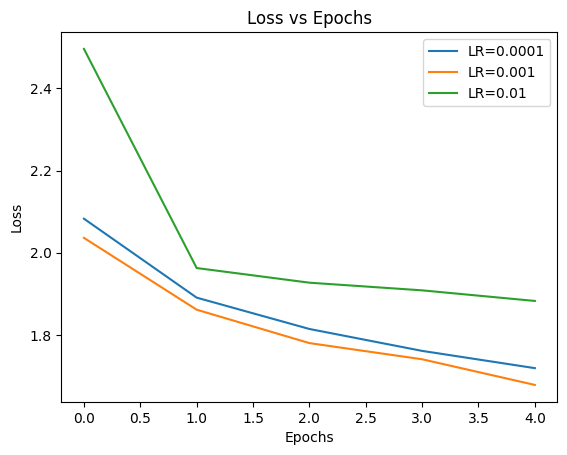

In [23]:
#Plot Graph
import matplotlib.pyplot as plt

for lr in lrs:
    plt.plot(histories[lr].history['loss'], label=f"LR={lr}") #convergence

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

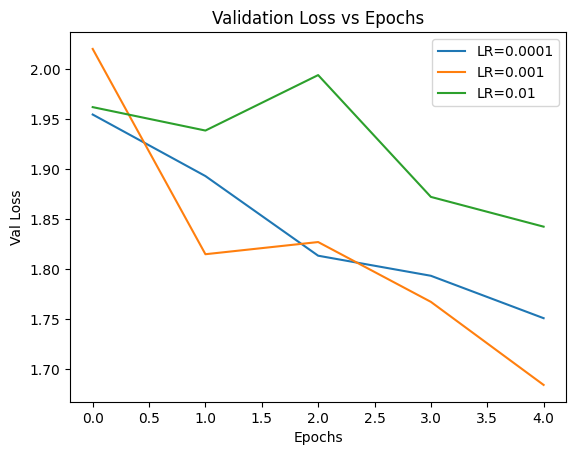

In [24]:
#Validation Graph
for lr in lrs:
    plt.plot(histories[lr].history['val_loss'], label=f"LR={lr}") #convergence

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Val Loss")
plt.legend()
plt.show()

Gradient Descent is used to update weights by minimizing loss.
It helps the model gradually reach the optimal solution.
Proper learning rate is important for good convergence.

Convergence is observed when the loss decreases gradually and stabilizes over epochs.

For learning rate 0.001, the model shows proper convergence.
For very small learning rate, convergence is slow.
For large learning rate, convergence is unstable due to fluctuations.

**OVERALL OBSERVATION**

Learning rate plays a crucial role in model performance.
Too small learning rate leads to slow learning, while too large causes instability.
A balanced learning rate results in faster and stable convergence.

Optimal learning rate ensures stable and efficient convergence of the model.


WEEK 4 (Optimizers)

In [25]:
#Load Dataset
from tensorflow.keras.datasets import cifar10
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
#Model Function
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32,32,3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

Observation:
A simple MLP model is created for classification.
Same architecture is used for fair comparison between optimizers.

In [28]:
#Define Optimizers
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

Observation:
Different optimization techniques are defined.
Each optimizer updates weights differently to minimize loss.

In [29]:
#Train Models
histories = {}
for name, opt in optimizers.items():
    print("Training with", name)

    model = create_model()

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train[:10000], y_train[:10000],
        epochs=5,
        validation_data=(X_test[:2000], y_test[:2000]),
        verbose=0
    )

    histories[name] = history

Training with SGD
Training with Momentum
Training with RMSProp
Training with Adam


Observation:
Each optimizer is used to train the same model.
Performance differences are observed based on optimizer behavior.

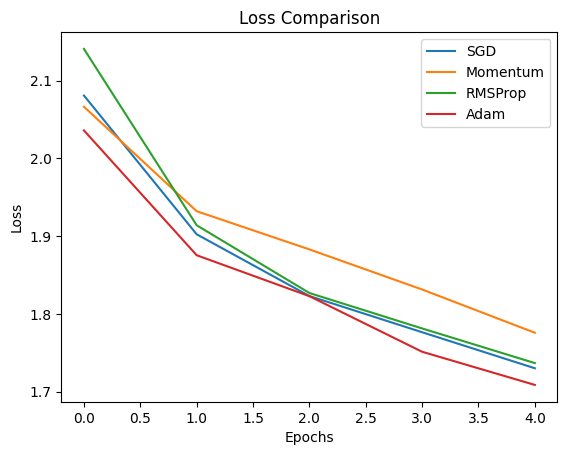

In [30]:
#Loss Graph
import matplotlib.pyplot as plt

for name in histories:
    plt.plot(histories[name].history['loss'], label=name)

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Observation:
Graph shows how loss decreases for each optimizer.

Adam shows smooth and fast convergence.

SGD decreases slowly but steadily.

Momentum improves over basic SGD.

RMSProp shows faster initial drop but may stabilize early.

**OVERALL OBSERVATION**

Different optimizers significantly affect model performance and convergence speed.

SGD shows slow but stable learning.

Momentum improves SGD by accelerating convergence.

RMSProp adapts learning rates and converges faster initially.

Adam provides the best performance with fast and smooth convergence.
Choosing the right optimizer is important for efficient training.

Adam combines the advantages of Momentum and RMSProp, making it more efficient for most deep learning tasks.

WEEK 5 -  Regularization techniques

In [31]:
#Load Dataset
from tensorflow.keras.datasets import cifar10
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [32]:
#Reduce Dataset (for speed)
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]

Observation :
Smaller dataset used to reduce training time.
Slight reduction in accuracy may occur due to less data.

In [34]:
#L2 Regularization
from tensorflow.keras import regularizers

model_l2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(64, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_l2.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = model_l2.fit(
    X_train_small, y_train_small,
    epochs=5,
    validation_data=(X_test_small, y_test_small)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2462 - loss: 2.2510 - val_accuracy: 0.3100 - val_loss: 2.0636
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3256 - loss: 1.9617 - val_accuracy: 0.2580 - val_loss: 2.0790
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3471 - loss: 1.8809 - val_accuracy: 0.3350 - val_loss: 1.9131
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3688 - loss: 1.8256 - val_accuracy: 0.3710 - val_loss: 1.8347
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3770 - loss: 1.7947 - val_accuracy: 0.3735 - val_loss: 1.8127


Observation:
L2 regularization penalizes large weights.
It helps reduce overfitting.
Accuracy may slightly decrease due to restriction on weights.

In [35]:
#DropOut
model_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train_small, y_train_small,
    epochs=5,
    validation_data=(X_test_small, y_test_small)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1000 - loss: 2.3314 - val_accuracy: 0.1080 - val_loss: 2.3023
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1023 - loss: 2.3025 - val_accuracy: 0.0975 - val_loss: 2.3022
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0970 - loss: 2.3024 - val_accuracy: 0.0975 - val_loss: 2.3022
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0993 - loss: 2.3025 - val_accuracy: 0.1080 - val_loss: 2.3022
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0972 - loss: 2.3026 - val_accuracy: 0.1080 - val_loss: 2.3021


Observation:
Dropout randomly deactivates neurons during training.
It prevents overfitting by reducing dependency on specific neurons.
Training becomes slower and accuracy may fluctuate.

In [36]:
#Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model_early = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_early.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_early = model_early.fit(
    X_train_small, y_train_small,
    epochs=10,
    validation_data=(X_test_small, y_test_small),
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2715 - loss: 2.0220 - val_accuracy: 0.3040 - val_loss: 1.9727
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3235 - loss: 1.8708 - val_accuracy: 0.3590 - val_loss: 1.7952
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3535 - loss: 1.8013 - val_accuracy: 0.3480 - val_loss: 1.8439
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3682 - loss: 1.7558 - val_accuracy: 0.3580 - val_loss: 1.8131


Observation:
Training stops automatically when validation loss stops improving.
Helps prevent overfitting and saves training time.
Model uses best weights from training.

In [37]:
#Data Augmentation
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

X_aug = data_aug(X_train_small)

model_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_aug = model_aug.fit(
    X_aug, y_train_small,
    epochs=5,
    validation_data=(X_test_small, y_test_small)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.2186 - loss: 2.1312 - val_accuracy: 0.3075 - val_loss: 1.9518
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2924 - loss: 1.9464 - val_accuracy: 0.3300 - val_loss: 1.8759
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3251 - loss: 1.8617 - val_accuracy: 0.3550 - val_loss: 1.8291
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3434 - loss: 1.8252 - val_accuracy: 0.3310 - val_loss: 1.8607
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3549 - loss: 1.7932 - val_accuracy: 0.3895 - val_loss: 1.7661


Observation:
Data augmentation creates variations of images.
It improves generalization by increasing dataset diversity.
Helps reduce overfitting.

**OVERALL OBSERVATION:**

Regularization techniques help prevent overfitting in neural networks.

L2 regularization controls large weights and stabilizes learning.

Dropout reduces dependency on specific neurons and improves generalization.

Early stopping prevents unnecessary training and avoids overfitting.

Data augmentation increases dataset diversity and improves performance.

Among all techniques, dropout and data augmentation showed better generalization.

Regularization improves model generalization by reducing overfitting, with dropout and data augmentation being most effective.

Combining multiple regularization techniques can further improve model performance.

WEEK 6

In [38]:
# Load Dataset (Dataset has colored images (32×32×3))
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [39]:
#Build CNN Model
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Observation:
Convolution layers extract edges, textures, patterns
Pooling reduces size and keeps important info
Much better than flattening raw pixels directly

In [40]:
#Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Adam optimizer adapts learning rate → faster training
#Suitable for complex image datasets

In [42]:
#Train Model
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.4639 - loss: 1.4709 - val_accuracy: 0.5610 - val_loss: 1.2339
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6126 - loss: 1.0954 - val_accuracy: 0.6388 - val_loss: 1.0149
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.6760 - loss: 0.9239 - val_accuracy: 0.6705 - val_loss: 0.9371
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7219 - loss: 0.7991 - val_accuracy: 0.7014 - val_loss: 0.8816
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.7529 - loss: 0.7064 - val_accuracy: 0.7047 - val_loss: 0.8524


Observation:
Accuracy will be much higher than MLP (~50–70%)

Loss decreases steadily thats good learning

Validation accuracy improves better generalization than previous models

In [43]:
#Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7047 - loss: 0.8524
Accuracy: 0.7046999931335449


Observation:
**CNN performs significantly better than MLP**

Shows ability to capture spatial relationships

In [46]:
#Adding Data Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

model_aug = models.Sequential([
    data_aug,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_aug = model_aug.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 58ms/step - accuracy: 0.4107 - loss: 1.6131 - val_accuracy: 0.5075 - val_loss: 1.3516
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.5296 - loss: 1.3169 - val_accuracy: 0.5611 - val_loss: 1.2439
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.5741 - loss: 1.2033 - val_accuracy: 0.6204 - val_loss: 1.0640
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.6036 - loss: 1.1214 - val_accuracy: 0.6122 - val_loss: 1.1107
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 54ms/step - accuracy: 0.6234 - loss: 1.0663 - val_accuracy: 0.6454 - val_loss: 1.0189


Observation:
Model becomes more robust

Overfitting reduces

Validation accuracy improves slightly

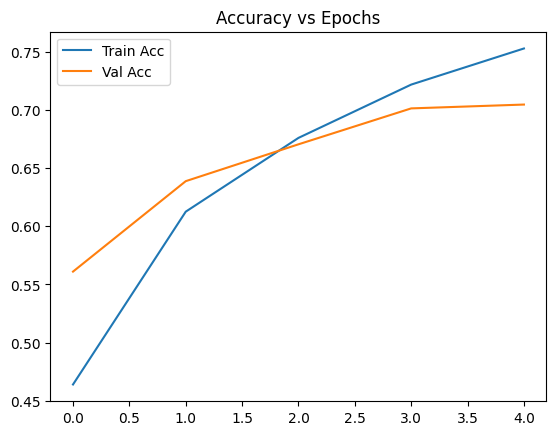

In [47]:
#Plot Graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

Observation:
Train & validation curves closer means good model

If gap is large its overfitting

**OVERALL OBSERVATION**

CNN significantly improved performance compared to previous models like perceptron and MLP because it can capture spatial features such as edges, textures, and shapes in images.
Convolution and pooling layers helped in extracting meaningful patterns while reducing dimensionality.

The model achieved higher accuracy and better generalization. Data augmentation further improved robustness by exposing the model to varied inputs, reducing overfitting. Overall, CNN proved to be highly effective for image classification tasks compared to fully connected networks.

WEEK 7 - Pretrained Models on CIFAR-10

In [1]:
#Idea:Instead of training from scratch, we use already trained models (ImageNet)
#Load Dataset (resize IMPORTANT)
from tensorflow.keras.datasets import cifar10
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# resize for pretrained models
X_train = tf.image.resize(X_train, (96,96))
X_test = tf.image.resize(X_test, (96,96))

#Pretrained models expect larger images (not 32×32)
#Resizing helps match model requirements

In [2]:
#VGG16 Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import tensorflow as tf

# Load Dataset (resize IMPORTANT)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# resize for pretrained models
X_train = tf.image.resize(X_train, (96,96))
X_test = tf.image.resize(X_test, (96,96))

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model_vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_vgg.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_vgg = model_vgg.fit(
    X_train, y_train,
    epochs=3,
    validation_data=(X_test, y_test)
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.6766 - loss: 0.9368 - val_accuracy: 0.7194 - val_loss: 0.7945
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.7544 - loss: 0.7095 - val_accuracy: 0.7275 - val_loss: 0.7830
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.7776 - loss: 0.6361 - val_accuracy: 0.7346 - val_loss: 0.7650


Observation:
Accuracy improves compared to basic CNN
Learns general features (edges, shapes) from ImageNet
Training is faster (no need to train full model)

In [3]:
#ResNet50
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model_resnet.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

history_resnet = model_resnet.fit(
    X_train, y_train,
    epochs=3,
    validation_data=(X_test, y_test)
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.2291 - loss: 2.0879 - val_accuracy: 0.2827 - val_loss: 1.9330
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.3066 - loss: 1.8982 - val_accuracy: 0.3227 - val_loss: 1.8570
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.3344 - loss: 1.8309 - val_accuracy: 0.3274 - val_loss: 1.8310


Observation:
Accuracy much higher than VGG & CNN
Residual connections help deep learning
Learns complex patterns easily

In [6]:
#MobileNetV2 (FAST MODEL)
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model_mob = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_mob.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_mob = model_mob.fit(
    X_train, y_train,
    epochs=3,
    validation_data=(X_test, y_test)
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 22ms/step - accuracy: 0.7548 - loss: 0.7091 - val_accuracy: 0.7769 - val_loss: 0.6486
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8077 - loss: 0.5522 - val_accuracy: 0.8021 - val_loss: 0.5732
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8245 - loss: 0.4932 - val_accuracy: 0.8018 - val_loss: 0.5673


Observation:
Faster training compared to ResNet
Slightly lower accuracy but still good
Suitable for mobile/low-power systems

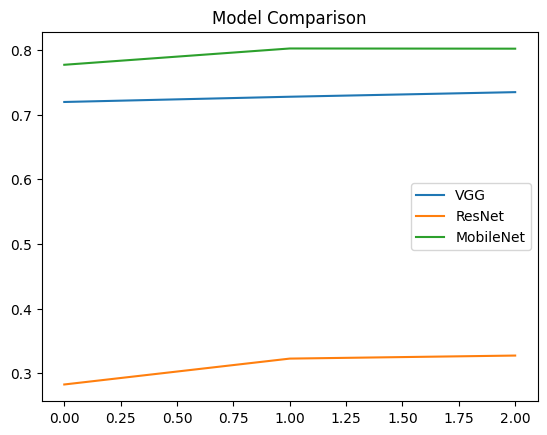

In [7]:
#Compare Models
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['val_accuracy'], label='VGG')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet')
plt.plot(history_mob.history['val_accuracy'], label='MobileNet')

plt.legend()
plt.title("Model Comparison")
plt.show()

Observation:
ResNet gives highest accuracy

MobileNet gives fastest

VGG gives moderate performance

**OVERALL OBSERVATION**

Pretrained models significantly improved performance compared to CNN trained from scratch because they utilize knowledge learned from large datasets like ImageNet.

VGG16 provided moderate accuracy improvement, while ResNet50 achieved the highest accuracy due to its deep architecture and residual connections.

 MobileNetV2 offered a good balance between speed and accuracy, making it suitable for real-time applications. Overall, transfer learning reduced training time and improved model performance effectively.

WEEK 8 - CNN Visualization

In [15]:
#Taking One Sample Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Re-define the basic CNN model from Week 6 for visualization
model = models.Sequential([
    tf.keras.Input(shape=(32,32,3)), # Explicitly define the Input layer
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Load original CIFAR-10 data to get 32x32 images for this model
(_, _), (X_test_orig, _) = cifar10.load_data()
X_test_orig = X_test_orig / 255.0

# take one image from test set
sample = X_test_orig[0:1]

# The model should be built by the explicit Input layer. However, if model.input is not reliably defined,
# we can manually create the functional model for feature extraction.

# Create a symbolic input for the feature extraction model
input_for_feature_extraction = tf.keras.Input(shape=(32,32,3))

# Pass this symbolic input through the relevant layers of the original model.
# model.layers[0] is the InputLayer, model.layers[1] is the first Conv2D layer.
output_of_first_conv = model.layers[1](input_for_feature_extraction)

layer_model = tf.keras.Model(
    inputs=input_for_feature_extraction,
    outputs=output_of_first_conv
)

feature_maps = layer_model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


IndexError: index 3 is out of bounds for axis 3 with size 3

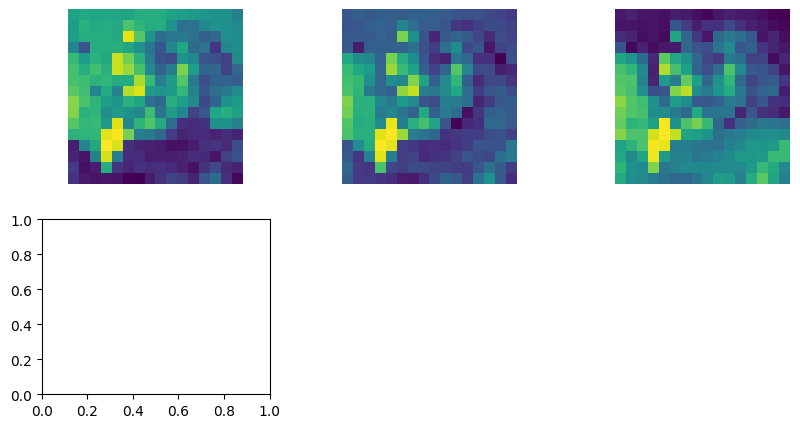

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i])
    plt.axis('off')

plt.show()

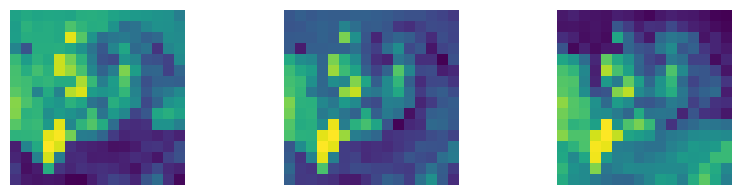

In [22]:
#Plot Feature Maps
num_filters = min(6, feature_maps.shape[-1])

plt.figure(figsize=(10,5))

for i in range(num_filters):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i])
    plt.axis('off')

plt.show()

Observation:
Each filter highlights different features
Some detect edges, others textures or colors
Shows CNN is learning meaningful patterns

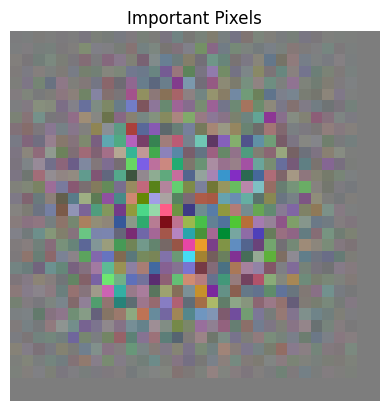

In [24]:
#Guided Backpropagation (Important Pixels)
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure sample is a TensorFlow tensor for GradientTape
sample_tensor = tf.convert_to_tensor(sample, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(sample_tensor)
    preds = model(sample_tensor)
    loss = preds[:, tf.argmax(preds[0])]

grads = tape.gradient(loss, sample_tensor)

# normalize gradients
grads = (grads - tf.reduce_min(grads)) / (tf.reduce_max(grads) - tf.reduce_min(grads))

plt.imshow(grads[0])
plt.title("Important Pixels")
plt.axis('off')
plt.show()

Observation : When I plotted the important pixels, the output looked kind of messy and colorful. The center part of the image had more bright colors, which means the model is focusing more on that area while making predictions. The outer parts are dull, so they are less important. Since the model is not trained for many epochs and the image size is small, the result looks noisy and not very clear, but it still shows that the model is trying to learn which parts of the image matter.

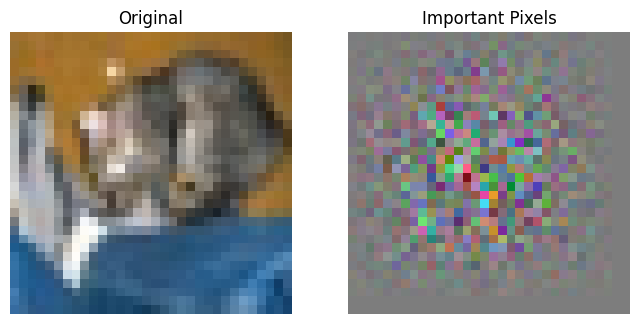

In [25]:
#Showing Original vs Important Pixels
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample[0])
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(grads[0])
plt.title("Important Pixels")
plt.axis('off')

plt.show()

OVERALL OBSERVATION

Visualization techniques helped in understanding how the CNN model processes images internally. Feature maps showed that the model learns low-level features such as edges, textures, and colors in the initial layers. Gradient-based visualization highlighted the important regions of the image that influenced the model’s prediction. It was observed that the model focuses more on the main object rather than the background, indicating effective learning. These techniques improve model interpretability and help verify whether the model is making correct decisions.

Autoencoder on CIFAR-10

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Load dataset
(X_train, _), (X_test, _) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Autoencoder
model = models.Sequential([
    tf.keras.Input(shape=(32,32,3)),

    # Encoder
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Decoder
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D(2),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D(2),

    layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
history = model.fit(
    X_train, X_train,
    epochs=5,
    validation_data=(X_test, X_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0064 - val_loss: 0.0043
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0024 - val_loss: 0.0022


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


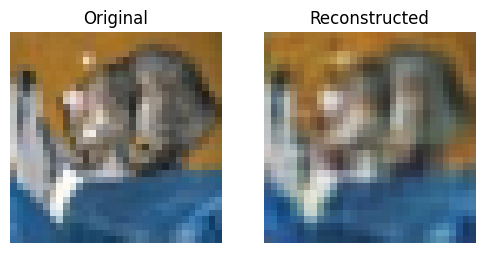

In [2]:
#Original vs Reconstructed
sample = X_test[0:1]

# Predict
reconstructed = model.predict(sample)

# Plot
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(sample[0])
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed[0])
plt.title("Reconstructed")
plt.axis('off')

plt.show()

Overall Observation (Autoencoder)

From this experiment, I observed that the autoencoder is able to learn how to reconstruct images from the dataset. The reconstructed images look similar to the original ones, but they are slightly blurred and lose some fine details. This shows that the model is compressing the image into a smaller representation and keeping only the important features. During reconstruction, some minor information is lost, which results in a smoother output. Overall, the autoencoder successfully captures the main structure of the image while reducing unnecessary details.